# 

# **Подготовка необходимых данных и графиков для отчета**

**Проект:** Анализ и визуализация данных с использованием Yandex DataLens: исследование по прогнозированию CTR

**Автор:** Грицан М.А., студент группы БПМИ-247, 2 курса

**Дата:** 26-03-2026  

**Цель:** Выделение, обрабаботка и агрегерация данных для таблиц/графиков/текстов главы 3 отчета курсовой работы  из набора данных с kaggle соревнования ["Avazu Click-Through Rate Prediction"](https://www.kaggle.com/competitions/avazu-ctr-prediction/data) 

#### Необходимые библиотеки и настройка графиков:

In [9]:
import gzip
import zipfile
from collections import Counter
from datetime import datetime

import os
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
%config InlineBackend.figure_format = 'retina'

sns.set(style='darkgrid', palette='deep')

plt.rcParams['figure.figsize'] = 8, 5
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'

### 0. Загрука набора данных c kaggle
Скачиваем все файлы с соревнования ["Avazu Click-Through Rate Prediction"](https://www.kaggle.com/competitions/avazu-ctr-prediction/data) для дальнейшего использования.

In [4]:
%pip install kaggle -q
!kaggle competitions download -c avazu-ctr-prediction -p ../

Note: you may need to restart the kernel to use updated packages.
100%|██████████████████████████████████████| 1.19G/1.19G [09:31<00:00, 2.23MB/s]



In [11]:
with zipfile.ZipFile('../avazu-ctr-prediction.zip', 'r') as zip_ref:
    zip_ref.extractall('../avazu-ctr-prediction')

### 1. Чтение данных

In [14]:
warnings.filterwarnings('ignore')

os.makedirs('data', exist_ok=True)

train_file = '../avazu-ctr-prediction/train.gz'
print(f"Загрузка данных из '{train_file}'...")

df = pd.read_csv(train_file, compression='gzip')
print(f"Прочитано {len(df)} строк, {len(df.columns)} колонок")

Загрузка данных из '../avazu-ctr-prediction/train.gz'...
Прочитано 40428967 строк, 24 колонок


### 2. Базовые характеристики набора данных

In [44]:
dt_series = pd.to_datetime(df['hour'], format='%y%m%d%H')
min_time = dt_series.min()
max_time = dt_series.max()

print(f"Размер: {f"{len(df):_}".replace("_", " ")} строк")
print(f"Период сбора: {(max_time - min_time)} ({min_time.date()} - {max_time.date()})")
print("Распеделение целевой переменной:")
display(df.value_counts("click", normalize=True))
print(f"Количество признаков: {len(df.columns) - 1}") # -1 из-за целевой переменной


Размер: 40 428 967 строк
Период сбора: 9 days 23:00:00 (2014-10-21 - 2014-10-30)
Распеделение целевой переменной:


click
0    0.830194
1    0.169806
Name: proportion, dtype: float64

Количество признаков: 23


### 3. Анализ категорий сайтов и приложений

In [79]:
n_top = 3

print("🌐 Категории сайтов (site_category):")
site_counts = df['site_category'].value_counts()
total_sites = len(df)

print(f"  Всего уникальных категорий: {len(site_counts)}")
print(f"  Топ-{n_top} категории сайтов:")

top_n_site_sum_pct = 0
top_n_site_count = 0

for i, (category, count) in enumerate(site_counts.head(n_top).items(), 1):
    percentage = (count / total_sites) * 100
    top_n_site_sum_pct += percentage
    top_n_site_count += count
    count_str = f"{count:_}".replace("_", " ")
    print(f"    {i}. {category}: {count_str} ({percentage:.2f}%)")

others_site_pct = 100 - top_n_site_sum_pct
others_site_count = total_sites - top_n_site_count

print(f"  Остальные категории: {others_site_pct:.2f}%")
print(f"  Сумма топ-{n_top}: {top_n_site_sum_pct:.2f}%")

print("\n" + "="*40 + "\n")

print("📱 Категории приложений (app_category):")
app_counts = df['app_category'].value_counts()
total_apps = len(df)

print(f"  Всего уникальных категорий: {len(app_counts)}")
print(f"  Топ-{n_top} категории приложений:")

top_n_app_sum_pct = 0
top_n_app_count = 0

for i, (category, count) in enumerate(app_counts.head(n_top).items(), 1):
    percentage = (count / total_apps) * 100
    top_n_app_sum_pct += percentage
    top_n_app_count += count
    count_str = f"{count:_}".replace("_", " ")
    print(f"    {i}. {category}: {count_str} ({percentage:.2f}%)")

others_app_pct = 100 - top_n_app_sum_pct
others_app_count = total_apps - top_n_app_count

print(f"  Остальные категории: {others_app_pct:.2f}%")
print(f"  Сумма топ-{n_top}: {top_n_app_sum_pct:.2f}%")

🌐 Категории сайтов (site_category):
  Всего уникальных категорий: 26
  Топ-3 категории сайтов:
    1. 50e219e0: 16 537 234 (40.90%)
    2. f028772b: 12 657 073 (31.31%)
    3. 28905ebd: 7 377 208 (18.25%)
  Остальные категории: 9.54%
  Сумма топ-3: 90.46%


📱 Категории приложений (app_category):
  Всего уникальных категорий: 36
  Топ-3 категории приложений:
    1. 07d7df22: 26 165 592 (64.72%)
    2. 0f2161f8: 9 561 058 (23.65%)
    3. cef3e649: 1 731 545 (4.28%)
  Остальные категории: 7.35%
  Сумма топ-3: 92.65%


In [80]:
print("💾 Сохранение результатов...")

site_pie_data = pd.DataFrame({
    'category': list(site_counts.head(n_top).index) + ['Остальные'],
    'count': list(site_counts.head(n_top).values) + [others_site_count],
    'percentage': list((site_counts.head(n_top) / total_sites) * 100) + [others_site_pct]
})

app_pie_data = pd.DataFrame({
    'category': list(app_counts.head(n_top).index) + ['Остальные'],
    'count': list(app_counts.head(n_top).values) + [others_app_count],
    'percentage': list((app_counts.head(n_top) / total_apps) * 100) + [others_app_pct]
})

site_pie_data.to_csv('data/site_category_pie.csv', index=False)
app_pie_data.to_csv('data/app_category_pie.csv', index=False)

print("✅ Результаты сохранены:")
print("   - data/site_category_pie.csv")
print("   - data/app_category_pie.csv")

💾 Сохранение результатов...
✅ Результаты сохранены:
   - data/site_category_pie.csv
   - data/app_category_pie.csv


In [81]:
print("Данные для круговых диаграмм:")

print("\n🌐 Сайты:")
print(site_pie_data.to_string(index=False))

print("\n" + "="*30 + "\n")

print("📱 Приложения:")
print(app_pie_data.to_string(index=False))

Данные для круговых диаграмм:

🌐 Сайты:
 category    count  percentage
 50e219e0 16537234   40.904419
 f028772b 12657073   31.306941
 28905ebd  7377208   18.247332
Остальные  3857452    9.541307


📱 Приложения:
 category    count  percentage
 07d7df22 26165592   64.719912
 0f2161f8  9561058   23.649029
 cef3e649  1731545    4.282932
Остальные  2970772    7.348127


### 4. Полный анализ периода данных

In [47]:
dt_series = pd.to_datetime(df['hour'], format='%y%m%d%H')

min_time = dt_series.min()
max_time = dt_series.max()

unique_dt = dt_series.drop_duplicates()
unique_dates = sorted(unique_dt.dt.date.unique())
unique_hours = len(unique_dt)

print(f"📈 Результаты:")
print(f"   Всего обработано строк: {len(df):,}")
print(f"   Уникальных часов: {unique_hours}")
print(f"   Уникальных дат: {len(unique_dates)}")

print(f"\n⏰ Временной период:")
print(f"   Начало: {min_time.strftime('%Y-%m-%d %H:00')}")
print(f"   Конец:  {max_time.strftime('%Y-%m-%d %H:00')}")

duration_days = (max_time.date() - min_time.date()).days + 1
print(f"   Длительность: {duration_days} дней ({unique_hours} часов)")

print(f"\n📅 Все даты в датасете:")
for i, date in enumerate(unique_dates, 1):
    print(f"   {i:2d}. {date.strftime('%Y-%m-%d')} ({date.strftime('%A')})")

hour_counts = unique_dt.dt.hour.value_counts().sort_index()
print(f"\n🕐 Покрытие по часам суток:")
hours_covered = len(hour_counts)
print(f"   Покрыто часов: {hours_covered}/24")

if hours_covered <= 24:
    for hour in range(24):
        count = hour_counts.get(hour, 0)
        if count > 0:
            print(f"   {hour:02d}:00 ✓ ({count} дней)")
        else:
            print(f"   {hour:02d}:00 ✗")

print("="*60)


📈 Результаты:
   Всего обработано строк: 40,428,967
   Уникальных часов: 240
   Уникальных дат: 10

⏰ Временной период:
   Начало: 2014-10-21 00:00
   Конец:  2014-10-30 23:00
   Длительность: 10 дней (240 часов)

📅 Все даты в датасете:
    1. 2014-10-21 (Tuesday)
    2. 2014-10-22 (Wednesday)
    3. 2014-10-23 (Thursday)
    4. 2014-10-24 (Friday)
    5. 2014-10-25 (Saturday)
    6. 2014-10-26 (Sunday)
    7. 2014-10-27 (Monday)
    8. 2014-10-28 (Tuesday)
    9. 2014-10-29 (Wednesday)
   10. 2014-10-30 (Thursday)

🕐 Покрытие по часам суток:
   Покрыто часов: 24/24
   00:00 ✓ (10 дней)
   01:00 ✓ (10 дней)
   02:00 ✓ (10 дней)
   03:00 ✓ (10 дней)
   04:00 ✓ (10 дней)
   05:00 ✓ (10 дней)
   06:00 ✓ (10 дней)
   07:00 ✓ (10 дней)
   08:00 ✓ (10 дней)
   09:00 ✓ (10 дней)
   10:00 ✓ (10 дней)
   11:00 ✓ (10 дней)
   12:00 ✓ (10 дней)
   13:00 ✓ (10 дней)
   14:00 ✓ (10 дней)
   15:00 ✓ (10 дней)
   16:00 ✓ (10 дней)
   17:00 ✓ (10 дней)
   18:00 ✓ (10 дней)
   19:00 ✓ (10 дней)
   20:0

### 5. Временная динамика показов и кликов

In [61]:
df['datetime'] = pd.to_datetime(df['hour'], format='%y%m%d%H')

hourly_stats = df.groupby('datetime').agg(
    impressions=('click', 'count'),
    clicks=('click', 'sum')
).reset_index()

hourly_stats['ctr'] = (hourly_stats['clicks'] / hourly_stats['impressions'] * 100).round(4)
hourly_stats = hourly_stats.sort_values('datetime')

hourly_stats['date'] = hourly_stats['datetime'].dt.date
hourly_stats['hour_of_day'] = hourly_stats['datetime'].dt.hour
hourly_stats['day_of_week'] = hourly_stats['datetime'].dt.day_name()

total_imp = f"{hourly_stats['impressions'].sum():_}".replace('_', ' ')
total_clicks = f"{hourly_stats['clicks'].sum():_}".replace('_', ' ')
mean_imp = f"{hourly_stats['impressions'].mean():_.0f}".replace('_', ' ')
max_imp = f"{hourly_stats['impressions'].max():_}".replace('_', ' ')
min_imp = f"{hourly_stats['impressions'].min():_}".replace('_', ' ')

print(f"✅ Создан временной ряд:")
print(f"   Период: {hourly_stats['datetime'].min()} - {hourly_stats['datetime'].max()}")
print(f"   Количество часов: {len(hourly_stats)}")
print(f"   Всего показов: {total_imp}")
print(f"   Всего кликов: {total_clicks}")
print(f"   Средний CTR: {hourly_stats['ctr'].mean():.4f}%")

print(f"\n📊 Статистика показов по часам:")
print(f"   Минимум: {min_imp}")
print(f"   Максимум: {max_imp}")
print(f"   Среднее: {mean_imp}")

✅ Создан временной ряд:
   Период: 2014-10-21 00:00:00 - 2014-10-30 23:00:00
   Количество часов: 240
   Всего показов: 40 428 967
   Всего кликов: 6 865 066
   Средний CTR: 17.2144%

📊 Статистика показов по часам:
   Минимум: 14 876
   Максимум: 447 783
   Среднее: 168 454


График успешно сохранен по пути: ../../typst/images/hourly_timeseries.png


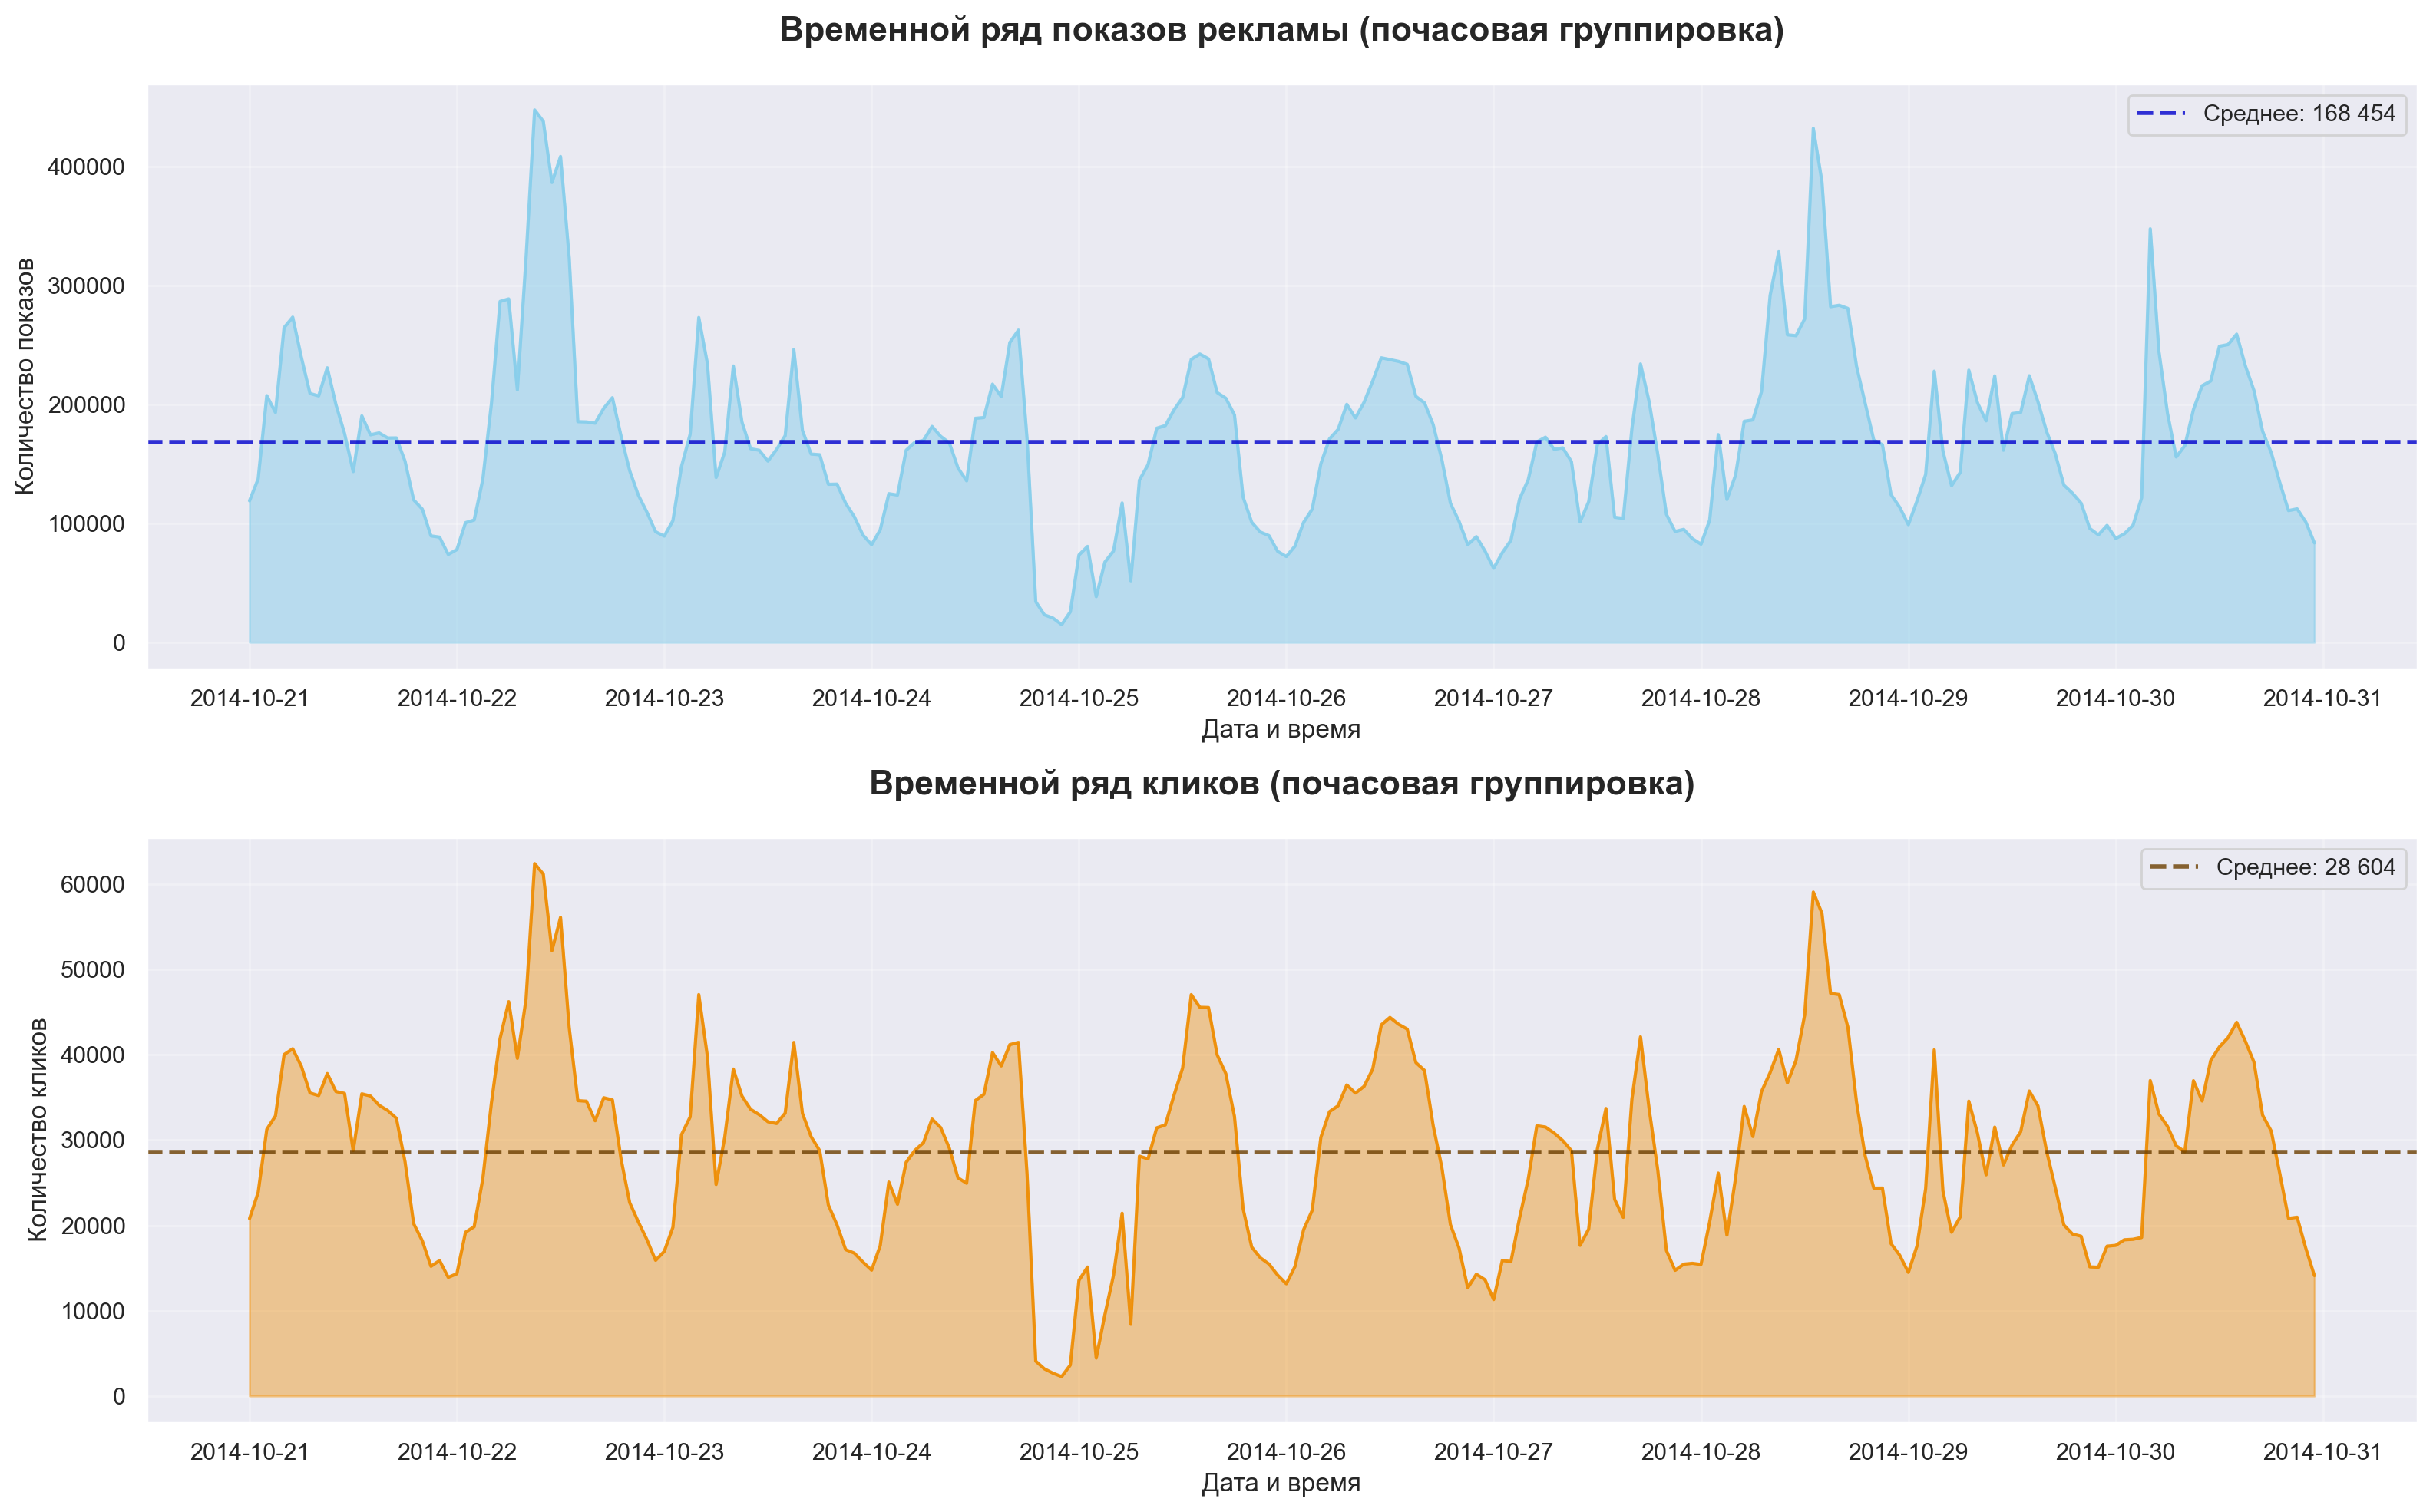

In [71]:
output_plot = '../../typst/images/hourly_timeseries.png'

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(hourly_stats['datetime'], hourly_stats['impressions'],
             linewidth=1.5, color='skyblue', alpha=0.9)
axes[0].fill_between(hourly_stats['datetime'], hourly_stats['impressions'],
                     alpha=0.5, color='skyblue')

axes[0].set_title('Временной ряд показов рекламы (почасовая группировка)',
                 fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel('Дата и время', fontsize=12)
axes[0].set_ylabel('Количество показов', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].ticklabel_format(style='plain', axis='y')

mean_impressions = hourly_stats['impressions'].mean()
label_imp = f"Среднее: {mean_impressions:_.0f}".replace('_', ' ')
axes[0].axhline(y=mean_impressions, color='mediumblue', linestyle='--',
               linewidth=2, alpha=0.8, label=label_imp)
axes[0].legend(fontsize=11)


axes[1].plot(hourly_stats['datetime'], hourly_stats['clicks'],
             linewidth=1.5, color='#EF8C00', alpha=0.9)
axes[1].fill_between(hourly_stats['datetime'], hourly_stats['clicks'],
                     alpha=0.4, color='#EF8C00')

axes[1].set_title('Временной ряд кликов (почасовая группировка)',
                 fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel('Дата и время', fontsize=12)
axes[1].set_ylabel('Количество кликов', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].ticklabel_format(style='plain', axis='y')

mean_clicks = hourly_stats['clicks'].mean()
label_clicks = f"Среднее: {mean_clicks:_.0f}".replace('_', ' ')
axes[1].axhline(y=mean_clicks, color='#6C3F00', linestyle='--',
               linewidth=2, alpha=0.8, label=label_clicks)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
print(f"График успешно сохранен по пути: {output_plot}")
plt.show()

### 6. Извлечение первых строк

In [50]:
n_rows = 10
df_head = df.head(n_rows)

csv_file = 'data/first_10_rows.csv'
df_head.to_csv(csv_file, index=False)
print(f"Сохранено в CSV: {csv_file}")

df_head

Сохранено в CSV: data/first_10_rows.csv


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157
5,1.000072e+19,0,14102100,1005,0,d6137915,bb1ef334,f028772b,ecad2386,7801e8d9,...,1,0,16920,320,50,1899,0,431,100077,117
6,1.000072e+19,0,14102100,1005,0,8fda644b,25d4cfcd,f028772b,ecad2386,7801e8d9,...,1,0,20362,320,50,2333,0,39,-1,157
7,1.000092e+19,0,14102100,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,0,20632,320,50,2374,3,39,-1,23
8,1.000095e+19,1,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15707,320,50,1722,0,35,-1,79
9,1.000126e+19,0,14102100,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,...,0,0,21689,320,50,2496,3,167,100191,23
